In [ ]:
from google.colab import files

uploaded = files.upload()


Saving diabetes_prediction_dataset.csv to diabetes_prediction_dataset.csv


In [ ]:
import pandas as pd

df = pd.read_csv('diabetes_prediction_dataset.csv')

display(df.head())

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


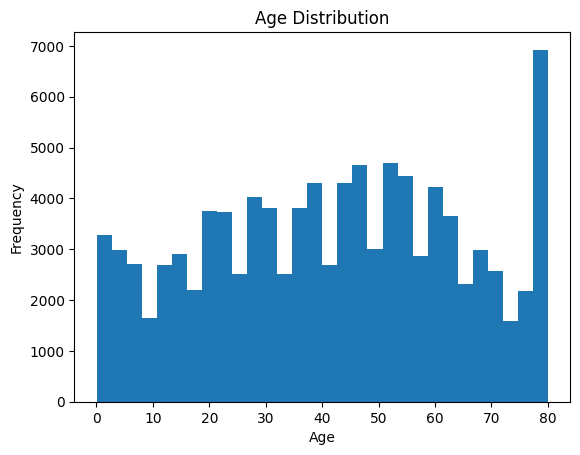

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df["age"], bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

In [ ]:
corr = df.select_dtypes(include="number").corr()

print(corr["diabetes"].sort_values(ascending=False))

diabetes               1.000000
blood_glucose_level    0.419558
HbA1c_level            0.400660
age                    0.258008
bmi                    0.214357
hypertension           0.197823
heart_disease          0.171727
Name: diabetes, dtype: float64


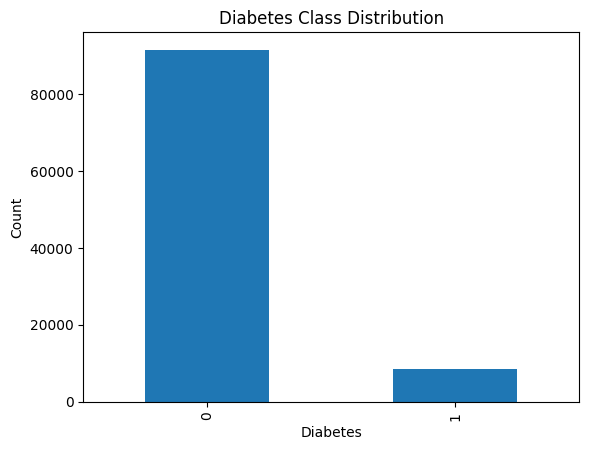

diabetes
0    91500
1     8500
Name: count, dtype: int64


In [ ]:
df["diabetes"].value_counts().plot(kind="bar")

plt.title("Diabetes Class Distribution")
plt.xlabel("Diabetes")
plt.ylabel("Count")
plt.show()

print(df["diabetes"].value_counts())

In [ ]:
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

Duplicate rows: 3854


In [ ]:
Q1 = df["bmi"].quantile(0.25)
Q3 = df["bmi"].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df[(df["bmi"] < lower_limit) | (df["bmi"] > upper_limit)]

print("BMI outliers:", outliers.shape[0])
print("Upper limit:", upper_limit)

BMI outliers: 7086
Upper limit: 38.504999999999995


In [ ]:
from sklearn.preprocessing import LabelEncoder

le_gender = LabelEncoder()
df['gender'] = le_gender.fit_transform(df['gender'])

le_smoking = LabelEncoder()
df['smoking_history'] = le_smoking.fit_transform(df['smoking_history'])
df[['gender', 'smoking_history']].head()

,gender,smoking_history
0,0,4
1,0,0
2,1,4
3,0,1
4,1,1


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numerical_cols = [
    'age',
    'bmi',
    'HbA1c_level',
    'blood_glucose_level'
]

df[numerical_cols] = scaler.fit_transform(df[numerical_cols])
df[numerical_cols].head()


,age,bmi,HbA1c_level,blood_glucose_level
0,1.692704,-0.321056,1.001706,0.047704
1,0.538006,-0.000116,1.001706,-1.426210
2,-0.616691,-0.000116,0.161108,0.489878
3,-0.261399,-0.583232,-0.492690,0.416183
4,1.515058,-1.081970,-0.679490,0.416183


In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('diabetes', axis=1)
y = df['diabetes']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(max_iter=1000)

baseline_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = baseline_model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.95875


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.99      0.98     18292
           1       0.86      0.61      0.72      1708

    accuracy                           0.96     20000
   macro avg       0.91      0.80      0.85     20000
weighted avg       0.96      0.96      0.96     20000



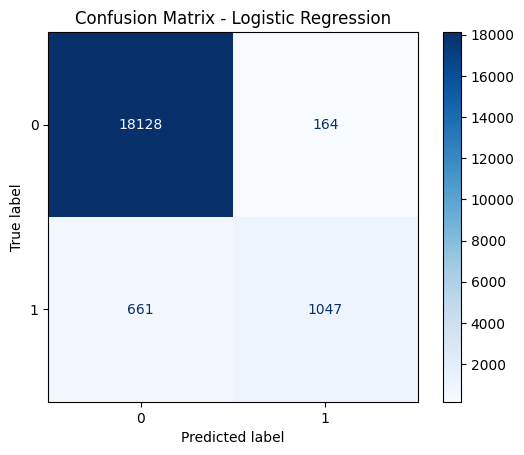

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    baseline_model,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Confusion Matrix - Logistic Regression")
plt.show()